In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Restaurant_Reviews.tsv", sep='\t')

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [2]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\fin
[nltk_data]     tic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\fin
[nltk_data]     tic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# liste des mots inutiles
stop_words = set(stopwords.words('english'))

# outil de lemmatisation
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [4]:
df['clean_review'] = df['Review'].apply(clean_text)

In [5]:
df[['Review', 'clean_review']].head()

,Review,clean_review
0,Wow... Loved this place.,wow loved place
1,Crust is not good.,crust good
2,Not tasty and the texture was just nasty.,tasty texture nasty
3,Stopped by during the late May bank holiday of...,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,selection menu great price


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [7]:
X = vectorizer.fit_transform(df['clean_review'])

In [8]:
y = df['Liked']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [11]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy Logistic Regression :", acc_lr)
print(classification_report(y_test, y_pred_lr))

Accuracy Logistic Regression : 0.735
              precision    recall  f1-score   support

           0       0.68      0.83      0.75        96
           1       0.81      0.64      0.72       104

    accuracy                           0.73       200
   macro avg       0.75      0.74      0.73       200
weighted avg       0.75      0.73      0.73       200



In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy Naive Bayes :", acc_nb)
print(classification_report(y_test, y_pred_nb))

Accuracy Naive Bayes : 0.77
              precision    recall  f1-score   support

           0       0.75      0.79      0.77        96
           1       0.80      0.75      0.77       104

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



In [13]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM :", acc_svm)
print(classification_report(y_test, y_pred_svm))

Accuracy SVM : 0.75
              precision    recall  f1-score   support

           0       0.72      0.78      0.75        96
           1       0.78      0.72      0.75       104

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



In [14]:
results_classic = pd.DataFrame({
    "Modèle": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        acc_lr,
        acc_nb,
        acc_svm
    ]
})

results_classic.sort_values(by="Accuracy", ascending=False)

,Modèle,Accuracy
1,Naive Bayes,0.770
2,SVM,0.750
0,Logistic Regression,0.735


In [15]:
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch

print("DistilBERT import OK")

c:\Users\fin tic\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DistilBERT import OK


In [16]:
df_bert = df[["Review", "Liked"]].copy()

df_bert.columns = ["text", "label"]

df_bert.head()

,text,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [17]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_bert["text"],
    df_bert["label"],
    test_size=0.2,
    random_state=42
)

In [18]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [19]:
class ReviewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = ReviewsDataset(
    train_encodings,
    train_labels
)

test_dataset = ReviewsDataset(
    test_encodings,
    test_labels
)

In [20]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1999.92it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./bert_logs",
    logging_steps=10,
    save_strategy="no",
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [22]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [23]:
trainer.train()

c:\Users\fin tic\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.691249
20,0.577349
30,0.322878
40,0.474483
50,0.294849
60,0.276382
70,0.331100
80,0.352963
90,0.217060
100,0.339876


TrainOutput(global_step=300, training_loss=0.1996127757926782, metrics={'train_runtime': 358.2766, 'train_samples_per_second': 6.699, 'train_steps_per_second': 0.837, 'total_flos': 26700460041600.0, 'train_loss': 0.1996127757926782, 'epoch': 3.0})

In [54]:
trainer.save_model("../models/distilbert_model")
tokenizer.save_pretrained("../models/distilbert_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


('../models/distilbert_model\\tokenizer_config.json',
 '../models/distilbert_model\\tokenizer.json')

In [24]:
predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(axis=1)

from sklearn.metrics import accuracy_score

bert_acc = accuracy_score(test_labels, preds)

print("Accuracy DistilBERT :", bert_acc)

Accuracy DistilBERT : 0.9


In [25]:
bert_result = pd.DataFrame({
    "Modèle": ["DistilBERT"],
    "Accuracy": [bert_acc]
})

results_final = pd.concat([results_classic, bert_result], ignore_index=True)

results_final.sort_values(by="Accuracy", ascending=False)

,Modèle,Accuracy
3,DistilBERT,0.900
1,Naive Bayes,0.770
2,SVM,0.750
0,Logistic Regression,0.735


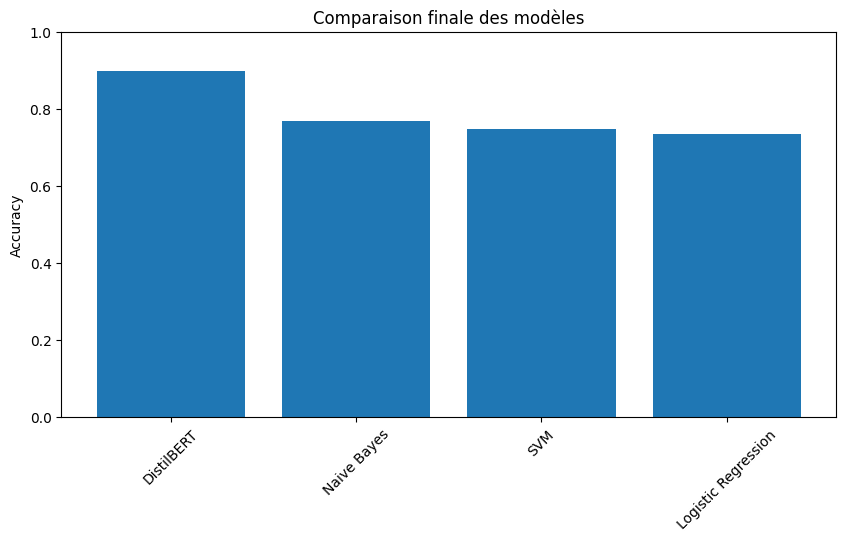

In [26]:
import matplotlib.pyplot as plt
results_final_sorted = results_final.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    results_final_sorted["Modèle"],
    results_final_sorted["Accuracy"]
)

plt.title("Comparaison finale des modèles")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

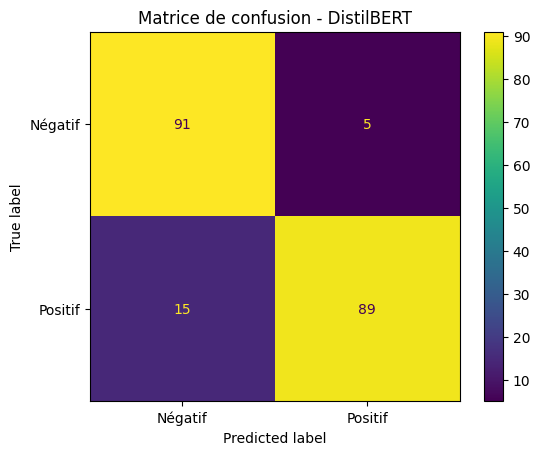

In [27]:
# Importer les outils pour créer la matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Créer la matrice de confusion
# test_labels = vraies valeurs
# preds = prédictions du modèle DistilBERT
cm = confusion_matrix(test_labels, preds)

# Préparer l'affichage de la matrice
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Négatif", "Positif"]
)

# Afficher la matrice de confusion
disp.plot()

# Ajouter un titre au graphique
plt.title("Matrice de confusion - DistilBERT")

# Afficher le graphique
plt.show()

In [28]:
# Precision, Recall, F1-score
# Importer classification_report
from sklearn.metrics import classification_report

# Afficher les métriques détaillées du modèle
# precision : fiabilité des prédictions positives/négatives
# recall : capacité du modèle à retrouver les vrais positifs/négatifs
# f1-score : équilibre entre precision et recall
print(
    classification_report(
        test_labels,
        preds,
        target_names=["Négatif", "Positif"]
    )
)

              precision    recall  f1-score   support

     Négatif       0.86      0.95      0.90        96
     Positif       0.95      0.86      0.90       104

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



In [29]:
# Prédiction avec score de confiance
# Importer torch et la fonction softmax
import torch
import torch.nn.functional as F

# Fonction pour prédire le sentiment d'un avis avec un score de confiance
def predict_with_confidence(text):
    
    # Transformer le texte en format compréhensible par DistilBERT
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Désactiver l'entraînement pendant la prédiction
    # Cela rend la prédiction plus rapide
    with torch.no_grad():
        outputs = bert_model(**inputs)

    # Transformer les scores du modèle en probabilités
    probabilities = F.softmax(outputs.logits, dim=1)

    # Récupérer la classe prédite : 0 ou 1
    predicted_class = torch.argmax(probabilities, dim=1).item()

    # Récupérer la confiance du modèle
    confidence = probabilities[0][predicted_class].item()

    # Convertir 0/1 en texte compréhensible
    sentiment = "Positif" if predicted_class == 1 else "Négatif"

    # Retourner le sentiment et le score de confiance
    return sentiment, confidence

In [30]:
# Tester la fonction avec un exemple
sentiment, confidence = predict_with_confidence(
    "The food was amazing but the service was slow"
)

# Afficher le sentiment détecté
print("Sentiment :", sentiment)

# Afficher le score de confiance en pourcentage
print("Confiance :", round(confidence * 100, 2), "%")

Sentiment : Négatif
Confiance : 91.48 %


In [31]:
# Détection des aspects
# Dictionnaire des aspects avec leurs mots-clés
# Chaque catégorie contient des mots associés
aspect_keywords = {
    "Service": ["service", "waiter", "staff", "employee", "slow", "rude"],
    "Qualité des plats": ["food", "meal", "dish", "taste", "flavor", "cold"],
    "Prix": ["price", "expensive", "cheap", "overpriced", "cost"],
    "Hygiène": ["dirty", "clean", "hygiene", "table", "bathroom"],
    "Ambiance": ["place", "music", "atmosphere", "ambience", "decor"]
}

# Fonction pour détecter les aspects présents dans un avis
def detect_aspects(text):
    
    # Mettre le texte en minuscule pour faciliter la recherche
    text_lower = text.lower()
    
    # Liste des aspects détectés
    detected = []

    # Parcourir chaque aspect et ses mots-clés
    for aspect, keywords in aspect_keywords.items():
        
        # Vérifier si un mot-clé de l'aspect existe dans l'avis
        for word in keywords:
            if word in text_lower:
                detected.append(aspect)
                break

    # Si aucun aspect n'est détecté
    if len(detected) == 0:
        detected.append("Autre")

    # Retourner les aspects détectés
    return detected

In [32]:
# Test 
# Exemple d'avis
review = "The food was good but the service was slow"

# Détecter les aspects
aspects = detect_aspects(review)

# Prédire le sentiment global
sentiment, confidence = predict_with_confidence(review)

# Afficher les résultats
print("Aspects détectés :", aspects)
print("Sentiment global :", sentiment)
print("Confiance :", round(confidence * 100, 2), "%")

Aspects détectés : ['Service', 'Qualité des plats']
Sentiment global : Négatif
Confiance : 99.24 %


In [33]:
# Fonction qui génère des recommandations selon les aspects détectés et le sentiment prédit
def generate_recommendations_from_aspects(aspects, sentiment):
    
    # Liste vide pour stocker les recommandations
    recommendations = []

    # Si le sentiment est négatif, on propose des actions correctives
    if sentiment == "Négatif":
        
        # Problème lié au service
        if "Service" in aspects:
            recommendations.append(
                "Améliorer la rapidité du service et former le personnel."
            )
        
        # Problème lié aux plats
        if "Qualité des plats" in aspects:
            recommendations.append(
                "Contrôler la qualité, le goût et la température des plats."
            )
        
        # Problème lié au prix
        if "Prix" in aspects:
            recommendations.append(
                "Revoir la politique tarifaire ou proposer des offres."
            )
        
        # Problème lié à l'hygiène
        if "Hygiène" in aspects:
            recommendations.append(
                "Renforcer les contrôles de propreté et d’hygiène."
            )
        
        # Problème lié à l'ambiance
        if "Ambiance" in aspects:
            recommendations.append(
                "Améliorer l’ambiance, le confort et l’expérience client."
            )
        
        # Si aucun problème précis n'a été identifié
        if len(recommendations) == 0:
            recommendations.append(
                "Analyser l’avis plus en détail pour identifier le problème."
            )

    # Si le sentiment est positif, on recommande de maintenir les points forts
    else:
        recommendations.append(
            "Maintenir les points forts identifiés dans cet avis."
        )

    # Retourner les recommandations
    return recommendations

In [34]:
# Test 
# Exemple d'avis négatif
review = "The service was slow and the food was cold"

# Prédire le sentiment avec confiance
sentiment, confidence = predict_with_confidence(review)

# Détecter les aspects mentionnés dans l'avis
aspects = detect_aspects(review)

# Générer des recommandations adaptées
recommendations = generate_recommendations_from_aspects(aspects, sentiment)

# Afficher les résultats
print("Sentiment :", sentiment)
print("Confiance :", round(confidence * 100, 2), "%")
print("Aspects :", aspects)
print("Recommandations :")

for rec in recommendations:
    print("-", rec)

Sentiment : Négatif
Confiance : 99.65 %
Aspects : ['Service', 'Qualité des plats']
Recommandations :
- Améliorer la rapidité du service et former le personnel.
- Contrôler la qualité, le goût et la température des plats.


In [35]:
## Extraction des mots-clés
from collections import Counter

# Rassembler tous les avis nettoyés
all_words = " ".join(df["clean_review"])

# Transformer le texte en liste de mots
words_list = all_words.split()

# Compter la fréquence de chaque mot
word_counts = Counter(words_list)

# Afficher les 20 mots les plus fréquents
top_keywords = word_counts.most_common(20)

top_keywords

[('food', 127),
 ('place', 111),
 ('good', 95),
 ('service', 87),
 ('great', 70),
 ('back', 61),
 ('time', 55),
 ('like', 47),
 ('go', 44),
 ('really', 36),
 ('best', 30),
 ('would', 29),
 ('ever', 28),
 ('restaurant', 28),
 ('also', 27),
 ('friendly', 27),
 ('one', 27),
 ('never', 26),
 ('nice', 25),
 ('amazing', 24)]

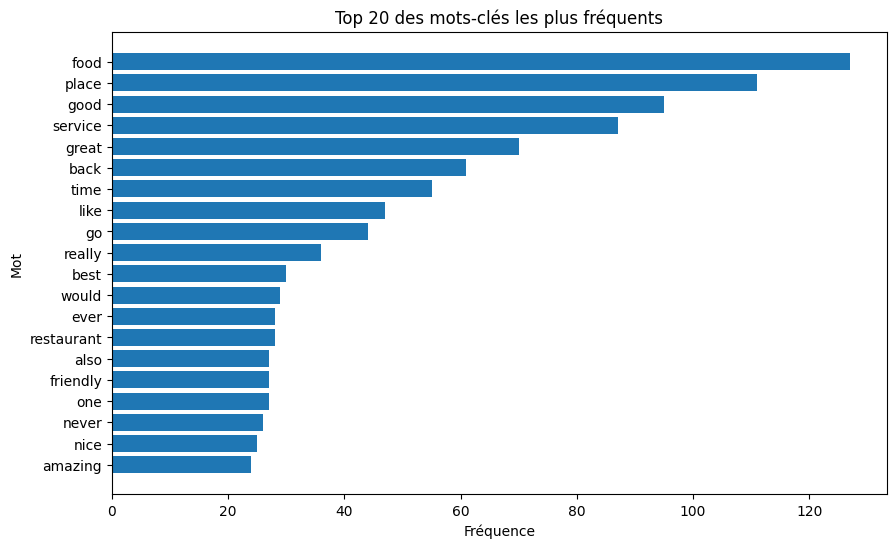

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

keywords_df = pd.DataFrame(top_keywords, columns=["word", "frequency"])

plt.figure(figsize=(10, 6))
plt.barh(keywords_df["word"], keywords_df["frequency"])
plt.title("Top 20 des mots-clés les plus fréquents")
plt.xlabel("Fréquence")
plt.ylabel("Mot")
plt.gca().invert_yaxis()
plt.show()

In [37]:
## Détection des thèmes / aspects
def detect_theme(review):
    review = review.lower()
    themes = []

    if any(word in review for word in ["service", "waiter", "staff", "employee", "served"]):
        themes.append("Service")

    if any(word in review for word in ["food", "meal", "dish", "taste", "flavor", "menu", "pizza", "burger"]):
        themes.append("Qualité des plats")

    if any(word in review for word in ["price", "expensive", "cheap", "overpriced", "cost"]):
        themes.append("Prix")

    if any(word in review for word in ["clean", "dirty", "hygiene", "table", "bathroom"]):
        themes.append("Hygiène")

    if any(word in review for word in ["slow", "wait", "waiting", "late", "time"]):
        themes.append("Temps d’attente")

    if any(word in review for word in ["ambience", "atmosphere", "music", "place", "decor"]):
        themes.append("Ambiance")

    if len(themes) == 0:
        themes.append("Autre")

    return themes

In [38]:
df["themes"] = df["Review"].apply(detect_theme)

df[["Review", "Liked", "themes"]].head()

,Review,Liked,themes
0,Wow... Loved this place.,1,[Ambiance]
1,Crust is not good.,0,[Autre]
2,Not tasty and the texture was just nasty.,0,[Autre]
3,Stopped by during the late May bank holiday of...,1,[Temps d’attente]
4,The selection on the menu was great and so wer...,1,"[Qualité des plats, Prix]"


In [39]:
themes_df = df.explode("themes")

themes_df[["Review", "Liked", "themes"]].head(6)

,Review,Liked,themes
0,Wow... Loved this place.,1,Ambiance
1,Crust is not good.,0,Autre
2,Not tasty and the texture was just nasty.,0,Autre
3,Stopped by during the late May bank holiday of...,1,Temps d’attente
4,The selection on the menu was great and so wer...,1,Qualité des plats
4,The selection on the menu was great and so wer...,1,Prix


In [40]:
## Calcul des KPIs
satisfaction_rate = df["Liked"].mean() * 100

print(f"Taux de satisfaction global : {satisfaction_rate:.2f}%")

Taux de satisfaction global : 50.00%


In [41]:
sentiment_counts = df["Liked"].map({1: "Positif", 0: "Négatif"}).value_counts()

sentiment_counts

Liked
Positif    500
Négatif    500
Name: count, dtype: int64

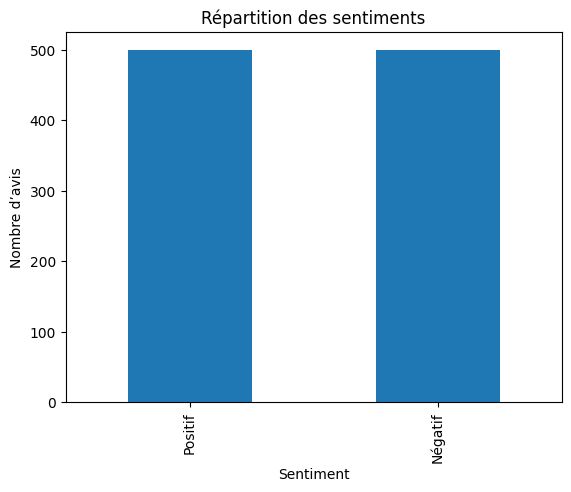

In [42]:
sentiment_counts.plot(kind="bar")
plt.title("Répartition des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d’avis")
plt.show()

In [43]:
theme_counts = themes_df["themes"].value_counts()

theme_counts

themes
Autre                483
Qualité des plats    229
Ambiance             127
Service              114
Temps d’attente      109
Hygiène               35
Prix                  34
Name: count, dtype: int64

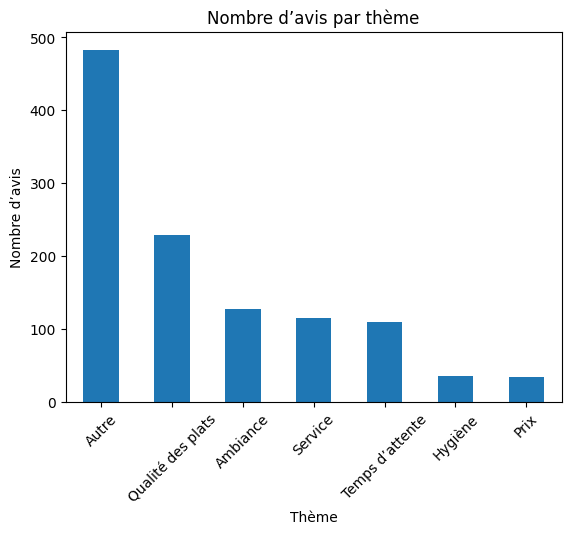

In [44]:
theme_counts.plot(kind="bar")
plt.title("Nombre d’avis par thème")
plt.xlabel("Thème")
plt.ylabel("Nombre d’avis")
plt.xticks(rotation=45)
plt.show()

In [45]:
theme_satisfaction = themes_df.groupby("themes")["Liked"].mean() * 100

theme_satisfaction.sort_values()

themes
Temps d’attente      34.862385
Hygiène              42.857143
Autre                47.619048
Qualité des plats    51.091703
Prix                 52.941176
Service              56.140351
Ambiance             58.267717
Name: Liked, dtype: float64

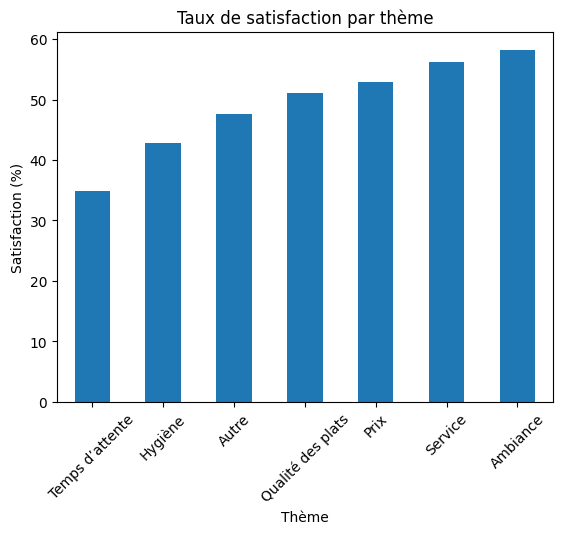

In [46]:
theme_satisfaction.sort_values().plot(kind="bar")
plt.title("Taux de satisfaction par thème")
plt.xlabel("Thème")
plt.ylabel("Satisfaction (%)")
plt.xticks(rotation=45)
plt.show()

In [47]:
negative_reviews = df[df["Liked"] == 0]

negative_words = " ".join(negative_reviews["clean_review"]).split()

negative_word_counts = Counter(negative_words)

top_negative_words = negative_word_counts.most_common(20)

top_negative_words

[('food', 67),
 ('place', 51),
 ('service', 40),
 ('back', 38),
 ('like', 29),
 ('time', 29),
 ('go', 26),
 ('good', 22),
 ('would', 22),
 ('never', 22),
 ('ever', 19),
 ('minute', 19),
 ('bad', 18),
 ('one', 17),
 ('much', 15),
 ('got', 15),
 ('worst', 14),
 ('really', 14),
 ('disappointed', 14),
 ('think', 13)]

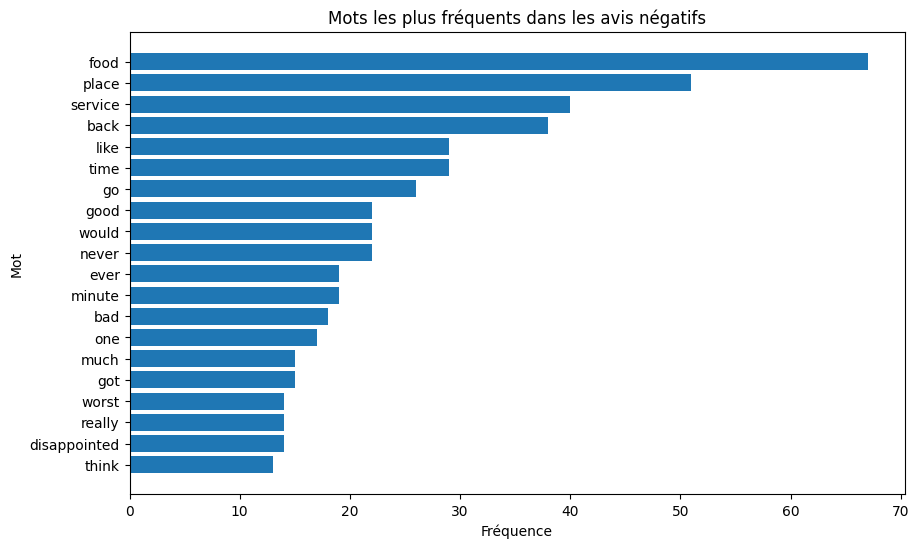

In [48]:
negative_keywords_df = pd.DataFrame(top_negative_words, columns=["word", "frequency"])

plt.figure(figsize=(10, 6))
plt.barh(negative_keywords_df["word"], negative_keywords_df["frequency"])
plt.title("Mots les plus fréquents dans les avis négatifs")
plt.xlabel("Fréquence")
plt.ylabel("Mot")
plt.gca().invert_yaxis()
plt.show()

In [49]:
## Génération d’insights
def generate_insights(theme_satisfaction, theme_counts):
    insights = []

    worst_theme = theme_satisfaction.idxmin()
    worst_score = theme_satisfaction.min()

    most_discussed_theme = theme_counts.idxmax()
    most_discussed_count = theme_counts.max()

    insights.append(
        f"Le thème le plus problématique est '{worst_theme}' avec un taux de satisfaction de {worst_score:.2f}%."
    )

    insights.append(
        f"Le thème le plus mentionné par les clients est '{most_discussed_theme}' avec {most_discussed_count} avis."
    )

    if worst_score < 50:
        insights.append(
            f"Priorité d'amélioration : travailler sur le thème '{worst_theme}' car il présente une satisfaction faible."
        )

    return insights

In [50]:
insights = generate_insights(theme_satisfaction, theme_counts)

for insight in insights:
    print("-", insight)

- Le thème le plus problématique est 'Temps d’attente' avec un taux de satisfaction de 34.86%.
- Le thème le plus mentionné par les clients est 'Autre' avec 483 avis.
- Priorité d'amélioration : travailler sur le thème 'Temps d’attente' car il présente une satisfaction faible.


In [51]:
def recommendation_agent(review):
    review = review.lower()
    recommendations = []

    if "slow" in review or "wait" in review or "waiting" in review or "late" in review:
        recommendations.append("Réduire le temps d’attente et améliorer l’organisation du service.")

    if "rude" in review or "staff" in review or "waiter" in review or "employee" in review:
        recommendations.append("Former le personnel à l’accueil, la communication et la relation client.")

    if "expensive" in review or "price" in review or "overpriced" in review:
        recommendations.append("Revoir la politique des prix ou proposer des formules promotionnelles.")

    if "cold" in review or "taste" in review or "bad food" in review or "food" in review:
        recommendations.append("Améliorer la qualité des plats et contrôler la température avant le service.")

    if "dirty" in review or "clean" in review or "hygiene" in review:
        recommendations.append("Renforcer le contrôle de propreté et d’hygiène du restaurant.")

    if len(recommendations) == 0:
        recommendations.append("Analyser plus en détail cet avis pour identifier la cause principale d’insatisfaction.")

    return recommendations

In [52]:
recommendation_agent("The service was slow and the waiter was rude")

['Réduire le temps d’attente et améliorer l’organisation du service.',
 'Former le personnel à l’accueil, la communication et la relation client.']

In [53]:
import joblib

joblib.dump(nb_model, "../models/sentiment_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")

['../models/vectorizer.pkl']